# **Introduction to LangGraph**

## **What's Covered?**
1. What is LangGraph?
2. Why is LangGraph powerful?
3. Key Components of LangGraph
    - State and Reducer
    - Nodes
    - Defining a Graph (Connecting Nodes with Edges)
    - Compiling a StateGraph
4. Visualizing the Graph
5. Graph with Multiple Inputs
6. An Example with Update Reducer
7. Limitations of Initializing State with Pydantic
8. Summary

## **What is LangGraph?**
**LangGraph** is an open-source framework built on top of **LangChain**, designed to help you build **stateful, multi-step LLM applications as graphs**.

It’s inspired by traditional computation graphs (like in Airflow or Ray) but optimized for LLM-first applications — think of workflows where the flow of execution is dynamic and dependent on LLM outputs, state, or external API responses.

In short:
> **LangGraph = LangChain + State Machine + Flow Control for LLM apps.**

Where LangChain focuses on creating modular chains (linear flows), LangGraph enables you to **Model applications as state machines or directed graphs**, where:
- Nodes can represent a sub-task like LLM calls, tool calls, or logic.
- Edges represent flow of execution i.e. transitions between nodes based on outcomes, conditions, or data.

LangGraph is ideal for:
1. Conversational agents with memory
2. Complex workflows involving decision trees
3. Multi-agent systems (e.g., agents that collaborate, debate, or vote)
4. Retry logic, conditional steps, and loops

In summary:
- LangGraph gives you fine-grained control over how your application progresses through each step, much like designing a **flowchart—but for LLMs and tools**.
- LangGraph also enables advanced features like loops, conditional branching, parallelism, resumability and statefulness - making it a goto choice for agentic production ready AI applications.
- It helps you model your workflows as a graph of nodes (tasks) and edges (routing) instead of a linear chain.

## **Why is LangGraph powerful?**

| Feature                     | Benefit                                                              |
| --------------------------- | -------------------------------------------------------------------- |
| **Graph-based execution**   | Go beyond linear chains—support branching, looping, and conditionals |
| **Stateful memory**         | Maintain memory or knowledge state between steps                     |
| **Multi-agent workflows**   | Simulate collaboration or reasoning between AI agents                |
| **Deterministic paths**     | Define exactly how your app flows based on output                    |
| **LangChain compatibility** | Fully compatible with LangChain tools and components                 |
| **Production-ready**        | Designed with retries, fallbacks, observability in mind              |

## **Key Components of LangGraph**
1. State and Reducer
2. Nodes
3. Defining a Graph (Connecting Nodes with Edges)
4. Compiling a StateGraph

### **1. State and Reducer**

#### **What is a State?**
**State** in LangGraph is a central shared dictionary (or object) that holds context as it moves through the graph. Each node can read from, modify, or add to the state.

State is the shared memory accessible to all nodes in your agent. Think of it as the notebook your agent uses to keep track of everything it learns and decides as it works through the process.

#### **What belongs in state?**  
Ask yourself these questions about each piece of data:
1. Does it need to persist across steps? If yes, it goes in state.
2. Can you derive it from other data? If yes, compute it when needed instead of storing it in state.

#### **What is a Reducer?**
**Reducer** defines how updates are applied to the shared state. Note that, each "key" in the state can have its own reducer, which determines whether new data overwrites (replaces) or concatinates (merges) to the existing value.

#### **How does State and Reducer work together?**
In LangGraph, you define a schema (typically a TypedDict) that declares which keys the state holds. A reducer is a function assigned to a specific key that executes whenever that key is updated. If no reducer is provided, the new value overwrites the old one.

When a node returns a value, LangGraph checks the reducer for the corresponding key. If you are tracking a list of messages, you typically use `operator.add` as a reducer to append new messages rather than replacing the entire list.

In [1]:
from typing import TypedDict

# Define a State
class TemperatureState(TypedDict):
    celsius: float      # Input
    fahrenheit: float   # Output

### **2. Nodes**
Now we implement each step as a function. A node in LangGraph is just a Python function that takes the current state and returns updates to it.

A node is a function (or LangChain component) that:
- Accepts a state as input
- Does something with it (e.g., call LLM, DB, tool)
- Returns an updated state

You can think of it as one step in your workflow.

#### **Common Errors**
1. **State Mutation:** Nodes should NEVER modify the **state** object they receive in-place internally. Because LangGraph manages state transitions and persistence, **mutating in-place modification bypasses the reducer logic**, leading to broken checkpoints and inconsistent state history. **Always return a new dictionary with the changes**.
2. **Serialization Mismatch:** If your node generates an object (like a custom class or a complex data structure) and tries to add it to the state, the **checkpointer** will fail if it cannot serialize that object. Ensure all data passed back from nodes to the state consists of basic types (strings, ints, lists, dicts) or objects that support standard serialization.
3. **Node Timeouts:** LangGraph nodes run synchronously by default. If a node is waiting on a slow external tool, it blocks the entire process. In high-concurrency production systems, you should either implement asynchronous nodes (async def) or offload long-running tasks to an external worker and treat the node as a status checker.
4. **Infinite Loops and Resource Exhaustion:** Nodes that trigger transitions back to themselves or previous nodes without proper conditional logic (using conditional_edges or "stop" criteria) will create infinite loops. Always ensure your node logic respects the current state and includes a "break" condition.
5. **Fatal Node Exceptions:** If a node raises an unhandled exception, the entire graph execution will halt. In production, you must implement **try/except** blocks inside your nodes to handle transient failures (e.g., API timeouts) or return a specific "error" state key that triggers a recovery path in your graph logic rather than a hard crash. 

In [2]:
def celsius2fahrenheit_converter(state: TemperatureState) -> TemperatureState:
    # 1. READ the input
    c_temp = state["celsius"]
    
    # 2. CALCULATE
    # Formula: (C * 9/5) + 32
    f_temp = (c_temp * 1.8) + 32

    # 3. WRITE the update
    state["fahrenheit"] = round(f_temp, 2)
    
    # 3. WRITE the update
    return state

#### **Issue:**
Even though you are returning the state at the end, LangGraph's internal architecture expects nodes to **return only the partial updates** to the state. When you modify the state directly, you bypass the state tracking mechanism, which can lead to unpredictable behavior in complex graphs (especially when using checkpointers).

In [3]:
def celsius2fahrenheit_converter(state: TemperatureState) -> dict:
    # 1. READ the input
    c_temp = state["celsius"]
    
    # 2. CALCULATE
    f_temp = (c_temp * 1.8) + 32

    # 3. WRITE the update (Return a new dict with the changes)
    # LangGraph will merge this into the existing state automatically
    return {"fahrenheit": round(f_temp, 2)}

### **3. Defining a Graph (Connecting Nodes with Edges)**

The Graph is the full computation DAG (Directed Acyclic Graph). It contains:
- State definition
- Nodes
- Edges

LangGraph uses StateGraph for this.

#### **What is an Edge?**
An edge connects one node to another. LangGraph supports:
- Static edges: direct transitions
- Conditional edges: choose next node based on logic or state

In [4]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(TemperatureState)

# Add Nodes
graph.add_node("c2f_node", celsius2fahrenheit_converter)

# Add Edges
graph.add_edge(START, "c2f_node")
graph.add_edge("c2f_node", END)

### **3. Compiling a StateGraph**
Once nodes and edges are added, you compile the graph and run it.

This step checks the logical graph structure and prepare it for execution.

In [5]:
workflow = graph.compile()

### **4. Invoking the Graph**

In [6]:
workflow.invoke({"celsius": 5})

{'celsius': 5, 'fahrenheit': 41.0}

### **Visualizing the Graph**

Here we could use three options:
1. Using Mermaid.ink API (does not require additional packages)
```python
from IPython.display import Image, display
# from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(Image(workflow.get_graph().draw_mermaid_png()))
```
2. Using Mermaid + Pyppeteer (requires `pip install pyppeteer`)
```python
import nest_asyncio

nest_asyncio.apply()  # Required for Jupyter Notebook to run async functions

display(
    Image(
        workflow.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=10,
        )
    )
)
```
3. Using graphviz (which requires `pip install graphviz`)
```python
try:
    display(Image(workflow.get_graph().draw_png()))
except ImportError:
    print(
        "You likely need to install dependencies for pygraphviz, see more here https://github.com/pygraphviz/pygraphviz/blob/main/INSTALL.txt"
    )
```

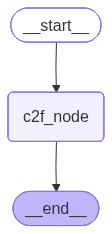

In [7]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

## **Graph with Multiple Inputs**

In [8]:
# Step 1: Defining a State
from typing import TypedDict, List

# Define a typed state
class AgentState(TypedDict):
    name: str
    values: List[int]
    response: str

In [9]:
# Step 2: Define a node

def processor_node(state: AgentState) -> dict:
    """This function takes a list and return the sum of all the values."""
    
    response = f"Hi {state['name']}, Sum of input list is {sum(state['values'])}."

    # RETURN the update as a dictionary
    # LangGraph will merge this into the existing state automatically
    return {"response": response}

In [10]:
# Step 3: Define a Graph

from langgraph.graph import StateGraph, START, END

graph = StateGraph(AgentState)

graph.add_node("node", processor_node)

graph.add_edge(START, "node")
graph.add_edge("node", END)

In [11]:
# Step 4: Compile the graph

app = graph.compile()

In [12]:
# Step 5: Invoke
app.invoke({"name": "ThatAIGuy", "values": [5, -1, 0, 2, 9]})

{'name': 'ThatAIGuy',
 'values': [5, -1, 0, 2, 9],
 'response': 'Hi ThatAIGuy, Sum of input list is 15.'}

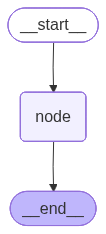

In [13]:
# Visualize the Graph

from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## **An Example with Update Reducer**

**Syntax**
```python
from operator import add

class State(TypedDict):
    messages: Annotated[list, add]
```

- The Base Type (list): This defines what the data actually is (e.g., a list, a string, an integer).
- The Metadata/Reducer (add): This is the function that the graph calls whenever a node returns an update for this key.

In LangGraph, you use **Annotated** specifically to tell the graph orchestrator: "When you update this key, don't just overwrite it; use this function to merge the new value with the old one."


#### **What are the different "Reducers" available?**
1. Overwriting (default) - operator.setitem
2. Appending - operator.add
    - operator.add works for int, float, str, list, and tuple because Python's + operator is overloaded for all of these types.
    - It will fail for dict. You cannot use add with a dict base type in Python (e.g., {"a": 1} + {"b": 2} will raise a TypeError).
    - If you use Annotated[int, add], the reducer will sum the numbers. If you use Annotated[str, add], the reducer will concatenate the strings.
3. Custom Reducer

Example of Custom Reducer:
```python
def keep_last_ten(old: list, new: list) -> list:
    # Combine lists and keep only the last 10 elements
    combined = old + new
    return combined[-10:]

class State(TypedDict):
    messages: Annotated[list, keep_last_ten]
```

In [14]:
from typing import Annotated, TypedDict
from operator import add

class State(TypedDict):
    foo: str
    bar: Annotated[list[str], add]

In [15]:
def node_a(state: State):
    return {"foo": "a", "bar": ["a"]}

def node_b(state: State):
    return {"foo": "b", "bar": ["b"]}

In [16]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(State)

workflow.add_node(node_a)
workflow.add_node(node_b)

workflow.add_edge(START, "node_a")
workflow.add_edge("node_a", "node_b")
workflow.add_edge("node_b", END)

In [17]:
graph = workflow.compile()

In [19]:
graph.invoke({"foo": "", "bar":[]})

{'foo': 'b', 'bar': ['a', 'b']}

## **Limitations of Initializing State with Pydantic**

- The validation error trace from pydantic does not show which node the error arises in.
- Pydantic’s recursive validation can be slow. For performance-sensitive applications, you may want to consider using a TypedDict instead.

Here is the way you will build a graph with Pydantic state. Note that, your Pydantic state requires all fields to have values on input because Pydantic validates the entire model before the node runs.

In [7]:
from pydantic import BaseModel, Field
from typing import Optional

# Define a State
class PydanticTemperatureState(BaseModel):
    celsius: float      # Input
    fahrenheit: Optional[float] = Field(default=None)   # Output with optional default

In [8]:
def celsius2fahrenheit_converter(state: PydanticTemperatureState) -> PydanticTemperatureState:
    # 1. READ the input
    c_temp = state.celsius
    
    # 2. CALCULATE
    # Formula: (C * 9/5) + 32
    f_temp = (c_temp * 1.8) + 32

    # 3. WRITE the update
    state.fahrenheit = round(f_temp, 2)
    
    # 3. WRITE the update
    return state

In [9]:
from langgraph.graph import StateGraph, START, END

pydantic_graph = StateGraph(PydanticTemperatureState)

# Add Nodes
pydantic_graph.add_node("c2f_node", celsius2fahrenheit_converter)

# Add Edges
pydantic_graph.add_edge(START, "c2f_node")
pydantic_graph.add_edge("c2f_node", END)

In [10]:
pydantic_workflow = pydantic_graph.compile()

In [11]:
pydantic_workflow.invoke({"celsius": 5})

{'celsius': 5.0, 'fahrenheit': 41.0}

## **Summary**

| Component       | Description                                                                                                                |
| --------------- | -------------------------------------------------------------------------------------------------------------------------- |
| `Node`       | A function or LangChain component (e.g., Chain, Tool, Agent) that performs a task. Each node receives and returns a state. |
| `Edge`       | A transition between nodes. Can be unconditional or conditional (based on output or state).                                |
| `Graph`      | A combination of nodes + edges. Represents the full workflow.                                                              |
| `State`      | A central dictionary that holds all context shared across nodes. Think of it like a memory store or a context object.      |
| `StateGraph` | A special LangGraph class that helps you define, validate, and execute your graph logic with type-safe states.             |